# 5. Diversity analysis
In this notebook, we performed alpha rarefaction, as well as alpha and beta diversity analyses.
### Import Packages

In [1]:
# Import all necessary packages
import os
import IPython
import pandas as pd
import matplotlib.pyplot as plt
import qiime2 as q2
from qiime2 import Visualization
%matplotlib inline

### Set Working Directory
Ensure that the working directory is correctly set to the 'scripts' folder within the main project directory. 
Otherwise, the file paths used in this notebook may not work properly.

In [2]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"

# Alpha Rarefaction

First, we perform alpha rarefaction to examine how sequencing depth affects within-sample diversity estimates (alpha diversity) and to help select an appropriate sampling depth.  

To do this, we need to determine the min_depth and max_depth values, which can be obtained by inspecting the feature table.


In [4]:
# Feature Table (if we decide to filter it before adjust this & could theoretically just import the visualization
! qiime feature-table summarize \
    --i-table $denoised_data_dir/dada2_table.qza \
    --m-sample-metadata-file $raw_data_dir/metadata.tsv \
    --o-visualization $denoised_data_dir/dada2_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/denoising/dada2_table.qzv


In [5]:
Visualization.load(f"{denoised_data_dir}/dada2_table.qzv")

<visualization: Visualization uuid: 8ab0c37e-c3a6-42c9-9f98-cee916c6d746>

In my opinion, a minimum sampling depth of 1 provides a useful reference point, so I decided to keep it, even though it clearly doesn't make sense to sample below 5'000 reads based on our feature table. For the maximum depth, I chose 55'000, since we definitely do not want to lose more than 3/4 of our data. I adjusted the step size to 15 to provide more detailed information between the data points.

In [18]:
! qiime diversity alpha-rarefaction \
    --i-table $denoised_data_dir/dada2_table.qza \
    --p-max-depth 55000 \
    --p-steps 15 \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --o-visualization $diversity_data_dir/alpha-rarefaction.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/alpha-rarefaction.qzv


In [4]:
Visualization.load(f"{diversity_data_dir}/alpha-rarefaction.qzv")

<visualization: Visualization uuid: 6075e0a2-85ec-4273-abbf-95032b8db9e2>

It is challenging to choose an appropriate sampling depth. In my opinion, the optimal depth lies somewhere between 10'000 and 20'000 reads, as higher sampling depths would result in losing too much data. I decided to use a sampling depth of 14'000, which retained 4'340'000 reads (26.54%) across 310 samples (86.83%).

# Diversity analysis
Next, we performed the core diversity analysis, which calculated diversity metrics including Jaccard distance, Bray-Curtis dissimilarity, observed species (richness) and Shannon entropy. The denoised feature table was rarefied to a sampling depth of 14'000 reads per sample to normalize for differences in sequencing depth.

In [33]:
! qiime diversity core-metrics \
  --i-table $denoised_data_dir/dada2_table.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-sampling-depth 10000 \
  --output-dir $diversity_data_dir/core-metrics-results

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/diversity/core-metrics-results/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/core-metrics-results/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/core-metrics-results/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/core-metrics-results/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/diversity/core-metrics-results/jaccard_distance_matrix.qza
Saved DistanceMatrix to: ../data/processed/diversity/core-metrics-results/bray_curtis_distance_matrix.qza
Saved PCoAResults to: ../data/proces

We also generated the k-mer–based diversity analysis results, rarefied to the same sampling depth and using a k-mer size of 8.

In [34]:
! qiime kmerizer core-metrics \
  --i-table  $denoised_data_dir/dada2_table.qza \
  --i-sequences $denoised_data_dir/dada2_rep_seq.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-sampling-depth 10000 \
  --p-kmer-size 8 \
  --output-dir $diversity_data_dir/kmerizer-results

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/diversity/kmerizer-results/rarefied_table.qza
Saved FeatureTable[Frequency] to: ../data/processed/diversity/kmerizer-results/kmer_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/kmerizer-results/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/kmerizer-results/shannon_vector.qza
Saved DistanceMatrix to: ../data/processed/diversity/kmerizer-results/jaccard_distance_matrix.qza
Saved DistanceMatrix to: ../data/processed/diversity/kmerizer-results/bray_curtis_distance_matrix.qza
Saved PCoAResults to: ../data/processed/diversity/kmerizer-results/j

## Alpha Diversity  
### Statistical Testing  
We first tested for associations between categorical metadata variables and alpha diversity metrics.

In [35]:
! qiime diversity alpha-group-significance \
  --i-alpha-diversity $diversity_data_dir/core-metrics-results/shannon_vector.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $diversity_data_dir/core-metrics-results/shannon-group-significance.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/core-metrics-results/shannon-group-significance.qzv


In [5]:
Visualization.load(f"{diversity_data_dir}/core-metrics-results/shannon-group-significance.qzv")

<visualization: Visualization uuid: 8cb87166-6ca8-4d77-b657-74e6f069ebc1>

Signifiant changes are only the country the children are from. Otherwise most categorical categories are just very close to eachother.

**Did I do something wrong? e.g. sampling depth)**

Next, we will test whether the age (numeric sample metadata column) are correlated with microbial community richness by using the qiime diversity alpha-correlation method (implementation of Spearman correlation).

In [37]:
! qiime diversity alpha-correlation \
  --i-alpha-diversity $diversity_data_dir/core-metrics-results/shannon_vector.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $diversity_data_dir/core-metrics-results/shannon-group-significance-numeric.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/core-metrics-results/shannon-group-significance-numeric.qzv


In [6]:
Visualization.load(f"{diversity_data_dir}/core-metrics-results/shannon-group-significance-numeric.qzv")

<visualization: Visualization uuid: 7de30992-8991-49b7-ae92-d79d2406fd18>

Age is significantly diverse.

## Beta Diversity

In [8]:
Visualization.load(f"{diversity_data_dir}/kmerizer-results/scatterplot.qzv")

<visualization: Visualization uuid: fc37115f-ee35-40c4-bc3f-cfbef27711e1>

It didn't cluster at all for me :( (but also it didn't clusteer nicely in the paper)

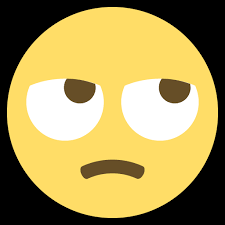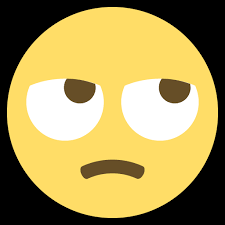

In [7]:
Visualization.load(f"{diversity_data_dir}/core-metrics-results/bray_curtis_emperor.qzv")

<visualization: Visualization uuid: 181641a3-1a8a-4784-938f-89136fc95f41>

same here :(